# Targeted Promotions and Association Rule Mining

The objective of this notebook is to identify purchasing patterns using association rule mining and develop targeted marketing strategies based on customer buying behaviour and the customer segments identified in the previous analysis.

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

customer_basket = pd.read_csv("customer_basket.csv")

In [116]:
customer_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [117]:
customer_basket.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 14.7 MB


In [118]:
# %pip install mlxtend

In [119]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [120]:
from ast import literal_eval

customer_basket['list_of_goods'] = customer_basket['list_of_goods'].apply(literal_eval)

In [121]:
type(customer_basket['list_of_goods'].iloc[0])

list

In [122]:
# Number of transactions

customer_basket.shape[0]

100000

In [123]:
# Average basket size

customer_basket['list_of_goods'].apply(len).mean()

np.float64(9.39975)

In [124]:
# Basket size distribution

customer_basket['list_of_goods'].apply(len).describe()

count    100000.000000
mean          9.399750
std           3.824795
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          18.000000
Name: list_of_goods, dtype: float64

The dataset contains 100,000 customer transactions. Each transaction consists of a list of purchased items. The average basket size was X items per transaction.

In [125]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(
    customer_basket['list_of_goods']
).transform(
    customer_basket['list_of_goods']
)

basket_matrix = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [126]:
basket_matrix.shape

(100000, 164)

In [127]:
basket_matrix.head()

,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,...,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [128]:
top_products = (
    basket_matrix.sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products

asparagus               12811
airpods                 12145
cereals                  9952
fresh bread              9934
butter                   9654
eggs                     9241
protein bar              8695
cooking oil              8623
toilet paper             8395
babies food              8318
dog food                 8192
energy bar               8117
milk                     8046
toothpaste               7973
oatmeal                  7794
energy drink             7525
tomatoes                 7460
napkins                  7342
bluetooth headphones     7279
green tea                7139
dtype: int64

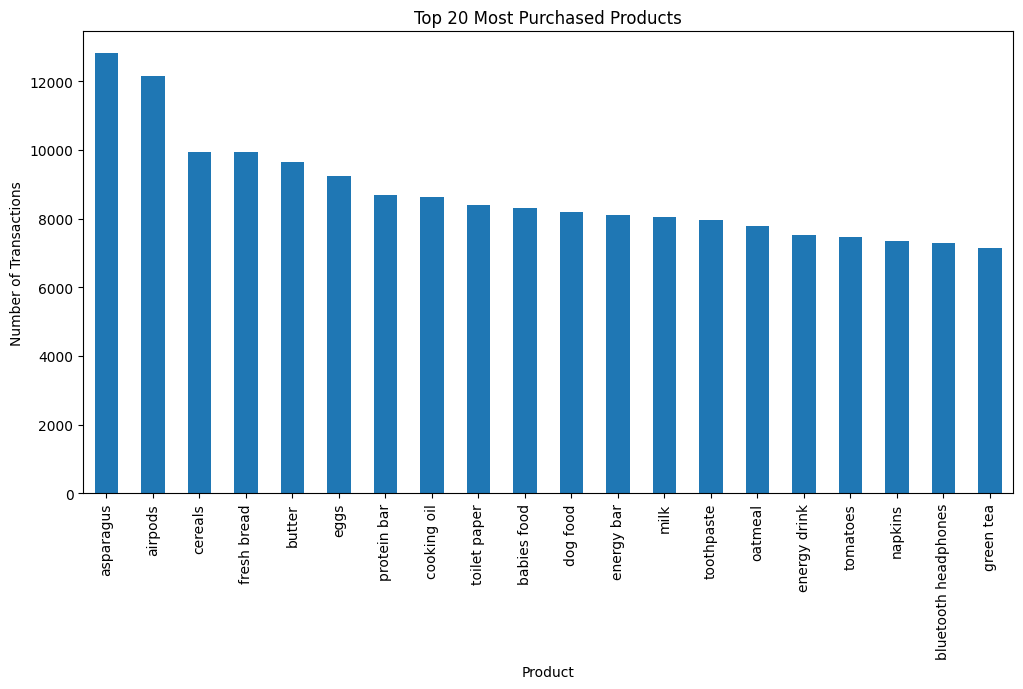

In [129]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 20 Most Purchased Products')
plt.ylabel('Number of Transactions')
plt.xlabel('Product')

plt.show()

The transaction dataset contains 100,000 baskets. After transforming the basket data into a one-hot encoded transaction matrix, the most frequently purchased products were identified. These products represent the strongest purchasing signals in the dataset and provide an initial understanding of customer buying behaviour before association rule mining.

## Frequent Itemset Mining using Apriori. 

The Apriori algorithm was used to identify frequently purchased product combinations. These itemsets form the basis for generating association rules that can be used to design targeted promotions.

### Viewing frequent itemsets.

In [130]:
frequent_itemsets = apriori(
    basket_matrix,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.12145,frozenset({airpods})
1,0.06409,frozenset({almonds})
2,0.06927,frozenset({antioxydant juice})
3,0.12811,frozenset({asparagus})
4,0.06664,frozenset({avocado})


In [131]:
frequent_itemsets.shape

(316, 2)

In [132]:
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
3,0.12811,frozenset({asparagus})
0,0.12145,frozenset({airpods})
26,0.09952,frozenset({cereals})
56,0.09934,frozenset({fresh bread})
18,0.09654,frozenset({butter})
45,0.09241,frozenset({eggs})
120,0.08695,frozenset({protein bar})
36,0.08623,frozenset({cooking oil})
146,0.08395,frozenset({toilet paper})
5,0.08318,frozenset({babies food})


## Generating association rules. 

In [133]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

In [134]:
rules = rules.copy()

rules['antecedents'] = rules['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules['consequents'] = rules['consequents'].apply(
    lambda x: ', '.join(list(x))
)

In [135]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,bluetooth headphones,airpods,0.07279,0.12145,0.02485,0.341393,2.810976,1.0,0.016010,1.333952,0.694828,0.146703,0.250348,0.273002
1,airpods,bluetooth headphones,0.12145,0.07279,0.02485,0.204611,2.810976,1.0,0.016010,1.165731,0.733312,0.146703,0.142169,0.273002
2,airpods,brownies,0.12145,0.06680,0.01368,0.112639,1.686212,1.0,0.005567,1.051658,0.463212,0.078364,0.049120,0.158715
3,brownies,airpods,0.06680,0.12145,0.01368,0.204790,1.686212,1.0,0.005567,1.104803,0.436085,0.078364,0.094861,0.158715
4,airpods,chocolate,0.12145,0.05232,0.01048,0.086291,1.649286,1.0,0.004126,1.037179,0.448099,0.064180,0.035846,0.143298


In [136]:
rules.shape

(292, 14)

In [137]:
rules.sort_values(
    by='lift',
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
280,shower gel,tooth brush,0.06679,0.06823,0.01521,0.227729,3.337662,1.0,0.010653,1.206532,0.750516,0.126951,0.171178,0.225326
281,tooth brush,shower gel,0.06823,0.06679,0.01521,0.222922,3.337662,1.0,0.010653,1.200923,0.751676,0.126951,0.167307,0.225326
270,shampoo,shower gel,0.06969,0.06679,0.01543,0.221409,3.315004,1.0,0.010775,1.198588,0.750654,0.127468,0.165685,0.226216
271,shower gel,shampoo,0.06679,0.06969,0.01543,0.231023,3.315004,1.0,0.010775,1.209801,0.748322,0.127468,0.173418,0.226216
198,shower gel,deodorant,0.06679,0.07095,0.01549,0.231921,3.268794,1.0,0.010751,1.209576,0.743752,0.126708,0.173264,0.225122
199,deodorant,shower gel,0.07095,0.06679,0.01549,0.218323,3.268794,1.0,0.010751,1.193856,0.747082,0.126708,0.162378,0.225122
196,shampoo,deodorant,0.06969,0.07095,0.01551,0.222557,3.136815,1.0,0.010565,1.195007,0.732235,0.123951,0.163185,0.220581
197,deodorant,shampoo,0.07095,0.06969,0.01551,0.218605,3.136815,1.0,0.010565,1.190575,0.733228,0.123951,0.160070,0.220581
274,shampoo,tooth brush,0.06969,0.06823,0.01491,0.213947,3.135681,1.0,0.010155,1.185379,0.732111,0.121210,0.156388,0.216237
275,tooth brush,shampoo,0.06823,0.06969,0.01491,0.218526,3.135681,1.0,0.010155,1.190455,0.730964,0.121210,0.159985,0.216237


In [140]:
strong_rules = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] > 1)
]

strong_rules.sort_values(
    by='lift',
    ascending=False
).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,bluetooth headphones,airpods,0.07279,0.12145,0.02485,0.341393,2.810976,1.0,0.016010,1.333952,0.694828,0.146703,0.250348,0.273002
8,energy drink,airpods,0.07525,0.12145,0.02525,0.335548,2.762850,1.0,0.016111,1.322218,0.689976,0.147273,0.243695,0.271726


In [141]:
# Converting the frozensets to strings for better readability in the output.
strong_rules['antecedents'] = strong_rules['antecedents']

strong_rules['consequents'] = strong_rules['consequents']
strong_rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,bluetooth headphones,airpods,0.07279,0.12145,0.02485,0.341393,2.810976,1.0,0.016010,1.333952,0.694828,0.146703,0.250348,0.273002
8,energy drink,airpods,0.07525,0.12145,0.02525,0.335548,2.762850,1.0,0.016111,1.322218,0.689976,0.147273,0.243695,0.271726


## Interpreting the rules. 

### Rule 1

Shower Gel -> Tooth Brush
    
    Interpretation:     
    - 1.52% of all transactions contain both shower gel and a toothbrush.
    - Among customers who buy shower gel, 22.8% also buy a toothbrush.
    - Customers who buy shower gel are 3.34 times more likely to buy a toothbrush than a random customer.

    Business Action:
    
    - Create a personal care bundle that combines shower gel and toothbrushes.
    - Place shower gel near toothbrushes in stores.

        - Example:
    
            - "Buy any shower gel and get 15% off a toothbrush.” 


### Rule 2

Shampoo -> Shower Gel

    Interpretation:
    - Customers buying shampoo are over 3 times more likely to buy shower gel.
    - This is another personal hygiene pattern.

    Business Action:
  
    - Offer a "Hair & Body Care” bundle.
    - Cross-sell shampoo whenever shower gel is added to the basket.

    - Example:

        - "Buy shampoo and get shower gel 20% off.”


### Rule 3

Shower Gel -> Deodorant

    Interpretation:
    - Customers buying shower gel are 3.27 times more likely to buy deodorant.

    Business Action: 

    - Bundle shower gel and deodorant.
    - Display shower gel promotions next to deodorant shelves.


### Rule 4 

Shampoo -> Deodorant

    Interpretation:
    - Shampoo buyers are over three times more likely to purchase deodorant.
    
    Business Action:

    - Hair-care and deodorant bundle promotion.


### Rule 5

Energy Drink -> Bluetooth Headphones

    Interpretation:
    - Customers buying energy drinks are almost 3 times more likely to purchase Bluetooth headphones.
    - This suggests a lifestyle segment:
        - young customers
        - gamers
        - students 
        - commuters
        - gym users

     Business Action:
     - Offer promotional and bundle deals.

     - Example:
        - ”Buy Bluetooth Headphones and get 2 Energy Drinks free."
        - Energy Drink + Headphones Student Bundle.


### Rule 6

Tooth Brush -> Toothpaste

    Interpretation:
    - The most obvious and practical rule.
    - Customers buying toothbrushes are nearly 3 times more likely to purchase toothpaste.

    Business Action:
    - "Buy a toothbrush and receive 25% off toothpaste.” 


## Overall Business Recommendations

### Customer Segmentation
Based on the shopping habits of each customer cluster: 
- Target Cluster 1 with premium offers.
- Target Cluster 0 with promotions.
- Target Cluster 2 with technology bundles.

### Association Rules
- Bundle personal care products.
- Cross-sell toothpaste and toothbrushes.
- Promote headphones alongside energy drinks.
  